In [59]:
import requests, time, math, re
from pathlib import Path
from datetime import datetime, date, timezone, timedelta
from typing import Dict, List, Optional, Tuple

try:
    from datetime import UTC          # Py3.11+
except ImportError:
    UTC = timezone.utc

BINANCE_BASE_URL = "https://api.binance.com"

# --- helpers / API ---
def to_symbol(coin: str, base: str) -> str | None:
    coin = coin.upper(); base = base.upper()
    if coin == base: return None
    return f"{coin}{base}"

def dt_utc_start(d: date) -> datetime:
    return datetime(d.year, d.month, d.day, tzinfo=timezone.utc)

def to_ms(dt: datetime) -> int:
    if dt.tzinfo is None:
        dt = dt.replace(tzinfo=timezone.utc)
    return int(dt.timestamp() * 1000)

def fetch_klines_1d(symbol: str, start_date: date, end_date: date,
                    timeout=10, retries=3, backoff=0.6) -> List[List]:
    params = {
        "symbol": symbol,
        "interval": "1d",
        "startTime": to_ms(dt_utc_start(start_date)),
        "endTime": to_ms(dt_utc_start(end_date + timedelta(days=1))) - 1,
        "limit": 1000
    }
    last_err = None
    for i in range(retries):
        try:
            r = requests.get(f"{BINANCE_BASE_URL}/api/v3/klines", params=params, timeout=timeout)
            r.raise_for_status()
            return r.json()
        except Exception as e:
            last_err = e
            if i == retries - 1: raise
            time.sleep(backoff * (2 ** i))
    raise last_err

def daily_close_map(symbol: str, start_date: date, end_date: date, only_closed: bool = True) -> Dict[str, float]:
    """
    Map UTC date 'YYYY-MM-DD' -> close price.
    If only_closed=True, skip the last candle if it hasn't closed yet.
    """
    rows = fetch_klines_1d(symbol, start_date, end_date)
    now_ms = int(datetime.now(UTC).timestamp() * 1000)
    m: Dict[str, float] = {}
    for row in rows:
        open_ms = row[0]
        close_px = float(row[4])
        close_time_ms = row[6]
        if only_closed and close_time_ms > now_ms:
            continue
        open_dt = datetime.fromtimestamp(open_ms / 1000.0, UTC)
        day = open_dt.date().isoformat()
        m[day] = close_px
    return m


def utc_day_list(start_date: date, end_date: date) -> List[str]:
    days = []
    cur = start_date
    while cur <= end_date:
        days.append(cur.isoformat())
        cur += timedelta(days=1)
    return days

In [60]:
MD_PATH = Path("/home/miu7898/coding/markdowns/Miu/Record.md")
md_text = MD_PATH.read_text(encoding="utf-8")


def get_section_lines(md: str, title: str):
    lines = md.splitlines()
    start = -1
    for i, ln in enumerate(lines):
        if ln.strip() == f"#### {title}:":
            start = i + 1
            break
    if start == -1:
        return []
    block = []
    for j in range(start, len(lines)):
        s = lines[j]
        if s.strip().startswith("#### "):
            break
        block.append(s)
    return block

def parse_holdings_block(lines):
    holdings = {}
    for ln in lines:
        s = ln.strip()
        if not s or s.startswith("#"): continue
        m = re.match(r"^([A-Za-z0-9]+)\s*:\s*([0-9]+(?:\.[0-9]+)?)\s*$", s)
        if not m: continue
        coin, amt = m.group(1).upper(), float(m.group(2))
        holdings[coin] = amt
    return holdings

def parse_settings_block(lines):
    kv = {}
    for ln in lines:
        s = ln.strip()
        if not s or s.startswith("#"): continue
        m = re.match(r"^([A-Za-z0-9_@:-]+)\s*:\s*(.+)$", s)
        if not m: continue
        k, v = m.group(1).strip(), m.group(2).strip()
        kv[k] = v
    return kv

def parse_date_flexible(s: str) -> date:
    s = s.strip()
    for fmt in ("%Y-%m-%d", "%Y/%m/%d", "%m/%d/%Y"):
        try:
            return datetime.strptime(s, fmt).date()
        except ValueError:
            pass
    raise ValueError(f"Unsupported date format: {s}")

# Read sections
holdings_lines = get_section_lines(md_text, "Holdings")
settings_lines = get_section_lines(md_text, "Settings")
holdings = parse_holdings_block(holdings_lines)
settings = parse_settings_block(settings_lines)

base = settings.get("Base", "USDT").upper()

start_date = parse_date_flexible(settings.get("Start", "2025-07-04"))
today_utc = datetime.now(UTC).date()
end_date = today_utc

if start_date > end_date:
    raise ValueError(f"Start date {start_date} is after end date {end_date}")

print("Holdings:", holdings)
print("Base:", base)
print("Date range:", start_date, "->", end_date)

def parse_auto_records_dates(md_text: str) -> list[date]:
    lines = get_section_lines(md_text, "Auto Records")
    out = []
    pat = re.compile(r"^(\d{4}-\d{2}-\d{2})\b")
    for ln in lines:
        s = ln.strip()
        if not s or s.startswith("#"):
            continue
        m = pat.match(s)
        if m:
            out.append(datetime.strptime(m.group(1), "%Y-%m-%d").date())
    out.sort()
    return out

def parse_auto_last_date_and_state(md_text: str) -> tuple[Optional[date], Optional[str]]:
    lines = get_section_lines(md_text, "Auto Records")
    for ln in reversed(lines):
        s = ln.strip()
        if not s or s.startswith("#"):
            continue
        m = re.match(r"^(\d{4}-\d{2}-\d{2})\b.*?(STATE=([A-Z]+))?", s)
        if m:
            d = datetime.strptime(m.group(1), "%Y-%m-%d").date()
            state = m.group(3)  # 'OPEN' or None
            return d, state
    return None, None

existing_auto_dates = parse_auto_records_dates(md_text)
last_auto_date, last_date_state = parse_auto_last_date_and_state(md_text)

# Do we want intraday for "today"?
include_today_open = True  # set False if you don't want intraday updates

# Base incremental range: (last + 1) -> today(UTC)
inc_start = (last_auto_date + timedelta(days=1)) if last_auto_date else start_date
inc_end = end_date

# If the last line was STATE=OPEN (yesterday when you wrote intraday), include it again to overwrite with the closed candle
if last_auto_date and last_date_state == "OPEN":
    inc_start = last_auto_date  # re-fetch to replace with closed price

# If we want intraday and we already have up to today(UTC), re-fetch "today" to overwrite with current partial price
if include_today_open and last_auto_date == end_date:
    inc_start = end_date
    inc_end = end_date

print("Last auto date:", last_auto_date, "state:", last_date_state)
print("inc_start/inc_end (UTC):", inc_start, inc_end)
print("include_today_open =", include_today_open, "| last_auto_date =", last_auto_date, "| last_date_state =", last_date_state)

Holdings: {'BTC': 0.10787429, 'ETH': 6.5919396, 'ADA': 10648.8979, 'SUI': 277.952, 'USDT': 0.0}
Base: USDT
Date range: 2025-07-04 -> 2025-08-26
Last auto date: 2025-08-25 state: None
inc_start/inc_end (UTC): 2025-08-26 2025-08-26
include_today_open = True | last_auto_date = 2025-08-25 | last_date_state = None


In [61]:
# Use incremental range instead of full start->end
if inc_start > inc_end:
    day_list = []
else:
    day_list = utc_day_list(inc_start, inc_end)

totals: Dict[str, float] = {}
per_coin_value: Dict[str, Dict[str, float]] = {}
missing_symbols: List[str] = []

if not day_list:
    print("[INFO] Auto Records already up to date. No fetch needed.")
else:
    totals = {d: 0.0 for d in day_list}
    per_coin_value = {d: {} for d in day_list}

    for coin, amount in holdings.items():
        coin = coin.upper()
        if coin == base:
            for d in day_list:
                v = amount * 1.0
                totals[d] += v
                per_coin_value[d][coin] = v
            continue

        symbol = to_symbol(coin, base)
        if symbol is None:
            continue

        # Past days use closed candles; if we want today's intraday, allow open candle
        cmap = daily_close_map(
            symbol,
            inc_start,
            inc_end,
            only_closed=not include_today_open
        )

        for d in day_list:
            px = cmap.get(d)
            if px is None:
                per_coin_value[d][coin] = math.nan
                continue
            v = amount * px
            totals[d] += v
            per_coin_value[d][coin] = v

    # (optional) drop days where all coins are NaN
    day_list = [d for d in day_list if any(not math.isnan(v) for v in per_coin_value[d].values())]

    if day_list:
        print(f"Incremental days fetched: {len(day_list)} from {day_list[0]} to {day_list[-1]} (UTC)")
    if missing_symbols:
        print("Missing symbols:", missing_symbols)


Incremental days fetched: 1 from 2025-08-26 to 2025-08-26 (UTC)


In [62]:
# ------- Functions ---------
def format_auto_record_line(day: str, base: str, total: float, per_coin: dict, *, state: Optional[str] = None) -> str:
    parts = []
    for k in sorted(per_coin.keys()):
        v = per_coin[k]
        if isinstance(v, float) and math.isnan(v):
            continue
        parts.append(f"{k}={v:.2f}")
    inside = ", ".join(parts)
    suffix = f", STATE={state}" if state else ""
    return f"{day} - TOTAL={total:.2f}, BASE={base}{suffix} [{inside}]"

def upsert_auto_records_block(md_text: str, new_lines: list[str]):
    lines = md_text.splitlines()
    # find start
    start = None
    for i, ln in enumerate(lines):
        if ln.strip() == "#### Auto Records:":
            start = i
            break

    date_re = re.compile(r'^(\d{4}-\d{2}-\d{2})\b')

    existing_map = {}
    if start is not None:
        end = len(lines)
        for j in range(start + 1, len(lines)):
            if lines[j].strip().startswith("#### "):
                end = j
                break
        for ln in lines[start + 1:end]:
            m = date_re.match(ln.strip())
            if m:
                existing_map[m.group(1)] = ln.strip()
        prefix = lines[:start]
        suffix = lines[end:]
    else:
        prefix = lines
        suffix = []

    new_map = {}
    for ln in new_lines:
        s = ln.strip()
        m = date_re.match(s)
        if m:
            new_map[m.group(1)] = s

    added_dates = sorted([d for d in new_map if d not in existing_map])
    updated_dates = sorted([d for d in new_map if d in existing_map])

    merged = dict(existing_map); merged.update(new_map)
    ordered_dates = sorted(merged.keys())
    block = ["#### Auto Records:"] + [merged[d] for d in ordered_dates]

    if prefix and prefix[-1].strip() != "":
        prefix = prefix + [""]

    out_lines = prefix + block + suffix
    out_text = "\n".join(out_lines)
    if not out_text.endswith("\n"):
        out_text += "\n"

    return out_text, added_dates, updated_dates

# ------- Actions ---------

if day_list:
    today_str = end_date.isoformat()  # end_date is UTC date
    auto_lines = []
    for d in day_list:
        state = "OPEN" if (include_today_open and d == today_str) else None
        auto_lines.append(
            format_auto_record_line(d, base, totals[d], per_coin_value[d], state=state)
        )
else:
    auto_lines = []

if not auto_lines:
    print("[INFO] No new lines to write (up to date).")
else:
    md_text = MD_PATH.read_text(encoding="utf-8")
    updated_text, added, updated = upsert_auto_records_block(md_text, auto_lines)

    if updated_text != md_text:
        MD_PATH.write_text(updated_text, encoding="utf-8")
        print(f"Auto Records updated at: {MD_PATH}")
        print(f"Added {len(added)} date(s): {added[:5]}{' ...' if len(added) > 5 else ''}")
        print(f"Updated {len(updated)} date(s): {updated[:5]}{' ...' if len(updated) > 5 else ''}")
    else:
        print("No changes (Auto Records already up to date).")

# Do the upsert
md_text = MD_PATH.read_text(encoding="utf-8")
updated_text, added, updated = upsert_auto_records_block(md_text, auto_lines)

if updated_text != md_text:
    MD_PATH.write_text(updated_text, encoding="utf-8")
    print(f"Auto Records updated at: {MD_PATH}")
    print(f"Added {len(added)} date(s): {added[:5]}{' ...' if len(added) > 5 else ''}")
    print(f"Updated {len(updated)} date(s): {updated[:5]}{' ...' if len(updated) > 5 else ''}")
else:
    print("No changes (Auto Records already up to date).")


Auto Records updated at: /home/miu7898/coding/markdowns/Miu/Record.md
Added 1 date(s): ['2025-08-26']
Updated 0 date(s): []
No changes (Auto Records already up to date).


Auto points: 54
First: 2025-07-04
Last : 2025-08-26


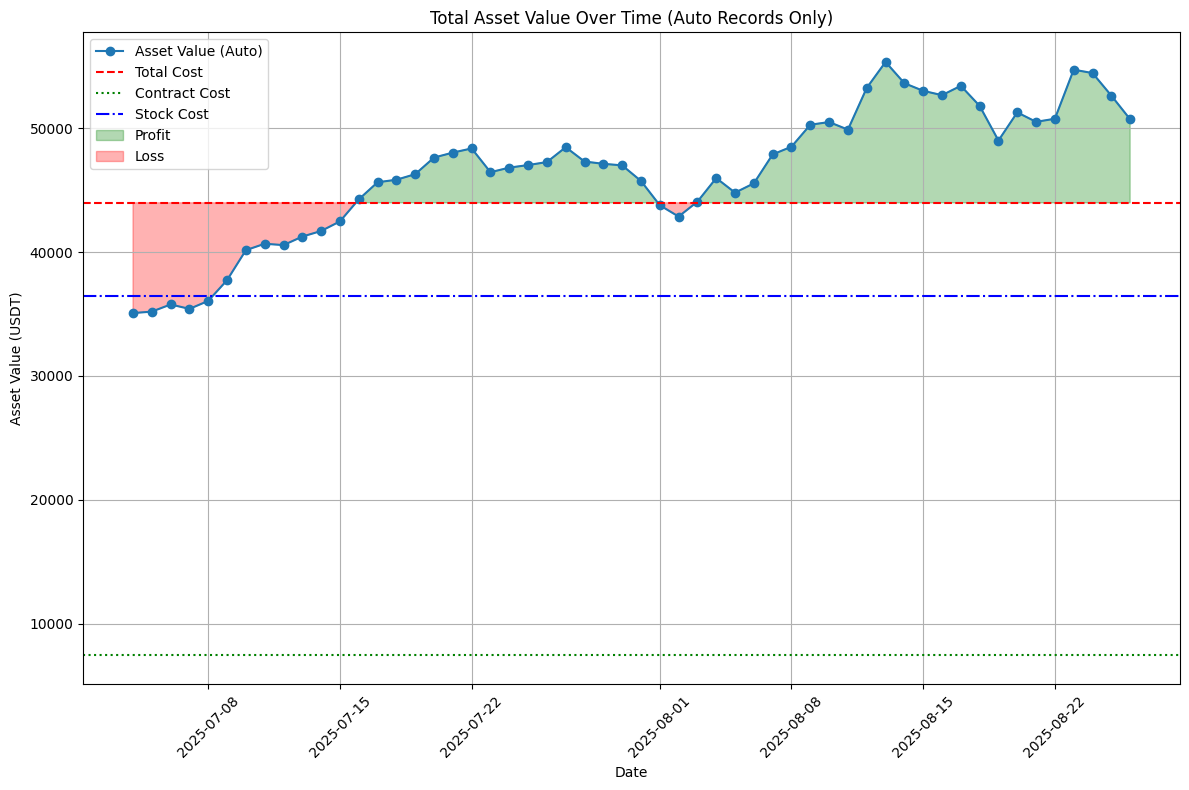

In [63]:
import matplotlib.pyplot as plt

# -------- Parse Costs / Manual Records / Auto Records --------
# (Re)load latest text after your Auto Records upsert
md_text = MD_PATH.read_text(encoding="utf-8")

def parse_costs(md_text: str):
    """
    Look for lines like:
      Contract: xxx.xx
      Stock: xxx.xx
      Total = xxx.xx
    Returns (contract_cost, stock_cost, total_cost) as floats or None if missing.
    """
    contract_cost = stock_cost = total_cost = None
    for ln in md_text.splitlines():
        s = ln.strip()
        m = re.match(r"^Contract\s*[:=]\s*([0-9]+(?:\.[0-9]+)?)\s*$", s, re.I)
        if m: contract_cost = float(m.group(1)); continue
        m = re.match(r"^Stock\s*[:=]\s*([0-9]+(?:\.[0-9]+)?)\s*$", s, re.I)
        if m: stock_cost = float(m.group(1)); continue
        m = re.match(r"^Total\s*[:=]\s*([0-9]+(?:\.[0-9]+)?)\s*$", s, re.I)
        if m: total_cost = float(m.group(1)); continue
    return contract_cost, stock_cost, total_cost

def parse_auto_records(md_text: str):
    """
    From '#### Auto Records:' lines like:
      2025-08-01 - TOTAL=xxxx.xx, BASE=USDT [...]
    Returns list of (datetime, total_value).
    """
    lines = get_section_lines(md_text, "Auto Records")
    rec = []
    pat = re.compile(r"^(\d{4}-\d{2}-\d{2})\s*-\s*TOTAL=([0-9]+(?:\.[0-9]+)?)\b")
    for ln in lines:
        s = ln.strip()
        if not s or s.startswith("#"):
            continue
        m = pat.match(s)
        if not m:
            continue
        day = datetime.strptime(m.group(1), "%Y-%m-%d")
        val = float(m.group(2))
        rec.append((day, val))
    return rec

# Parse inputs
contract_cost, stock_cost, total_cost = parse_costs(md_text)
auto = parse_auto_records(md_text)

if not auto:
    print("[INFO] No Auto Records found to plot.")
else:
    plot_dates = [dt for dt, _ in auto]
    plot_values = [v for _, v in auto]

    print(f"Auto points: {len(plot_dates)}")
    print("First:", plot_dates[0].date())
    print("Last :", plot_dates[-1].date())

    # -------------- Plot --------------
    plt.figure(figsize=(12, 8))

    # Asset value curve from Auto only
    plt.plot(plot_dates, plot_values, marker='o', label='Asset Value (Auto)')

    # Cost lines (optional)
    if total_cost is not None:
        plt.axhline(y=total_cost, linestyle='--', label='Total Cost', color='red')
    if contract_cost is not None:
        plt.axhline(y=contract_cost, linestyle=':', label='Contract Cost', color='green')
    if stock_cost is not None:
        plt.axhline(y=stock_cost, linestyle='-.', label='Stock Cost', color='blue')

    # Profit/Loss shading vs Total Cost
    if total_cost is not None:
        above = [v >= total_cost for v in plot_values]
        below = [not x for x in above]
        plt.fill_between(plot_dates, plot_values, total_cost, where=above,
                         interpolate=True, alpha=0.3, color='green', label='Profit')
        plt.fill_between(plot_dates, plot_values, total_cost, where=below,
                         interpolate=True, alpha=0.3, color='red', label='Loss')

    plt.xticks(rotation=45)
    plt.title("Total Asset Value Over Time (Auto Records Only)")
    plt.xlabel("Date")
    plt.ylabel(f"Asset Value ({settings.get('Base','USDT')})")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()